# Lesson 12: Graph Features for Machine Learning

## Learning Objectives

By the end of this lesson, you will:
- **Engineer graph features** for machine learning models
- **Extract centrality, community, structural, and neighborhood features** from graph algorithms
- **Train and compare classification models** (Logistic, Random Forest, XGBoost)
- **Analyze feature importance** to understand which graph patterns predict outcomes
- **Apply graph ML** to real-world business problems

## Problem Statement

**Question**: Can we predict document status (active vs inactive) from its graph position?

**Hypothesis**: Documents that are centrally positioned in the knowledge graph, part of large communities, and densely connected to similar documents are more likely to be active.

**Why It Matters**:
- Identify documents at risk of becoming obsolete
- Route documents to correct owners based on patterns
- Recommend similar documents for policy consolidation
- Discover hidden knowledge dependencies

## Prerequisites

- ✅ Lesson 11: Neo4j GDS algorithms (PageRank, Louvain, degree centrality)
- ✅ Python packages: pandas, scikit-learn, xgboost, shap, matplotlib
- ✅ Neo4j connection with document_policy graph loaded

---
# Part 1: Setup & Feature Engineering Foundations

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from graphdatascience import GraphDataScience
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠ XGBoost not available. Install with: pip install xgboost")

# SHAP is optional - used for advanced feature importance only
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")
print(f"  XGBoost: {'✓ Available' if xgb_available else '✗ Not available'}")
print(f"  SHAP: {'✓ Available' if shap_available else '(optional)'}")


✓ Imports successful
  XGBoost: ✓ Available
  SHAP: ✓ Available


In [2]:
# Neo4j connection parameters
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "your_password_here"

neo4j_available = False
driver = None
gds = None

try:
    import socket
    
    # Quick socket test to fail fast if Neo4j is not reachable (no retries)
    def is_port_open(host, port, timeout=1):
        sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        sock.settimeout(timeout)
        try:
            result = sock.connect_ex((host, port))
            return result == 0
        finally:
            sock.close()
    
    print("Checking Neo4j availability...")
    if not is_port_open("localhost", 7687, timeout=2):
        raise ConnectionError("Neo4j port 7687 is not accessible. Is the container running? Run: docker-compose up -d")
    
    print("Connecting to Neo4j...")
    driver = GraphDatabase.driver(
        NEO4J_URI, 
        auth=(NEO4J_USERNAME, NEO4J_PASSWORD), 
        encrypted=False,
        connection_timeout=5
    )
    gds = GraphDataScience(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    
    # Test connection
    with driver.session() as session:
        result = session.run("RETURN 'Connected!' as msg")
        msg = result.single()[0]
    
    print(f"✓ {msg} - Neo4j is responding")
    gds_version = gds.version()
    print(f"✓ GDS client connected (version {gds_version})")
    
    neo4j_available = True
    
except Exception as e:
    print(f"⚠ Neo4j not available: {str(e)[:100]}")
    print("  Using synthetic data for demonstration")
    print("  To use real data, run: docker-compose up -d")
    driver = None
    gds = None
    neo4j_available = False


Checking Neo4j availability...
Connecting to Neo4j...
✓ Connected! - Neo4j is responding
✓ GDS client connected (version 2.6.9)


---
# Part 2: Feature Engineering — Extract Graph Features

## Feature Engineering Concept

We will extract **4 categories of features** from the document graph:

### 1. **Centrality Features** — How important is this document?
- PageRank score (from Lesson 11)
- In-degree centrality (how many docs reference it)
- Out-degree centrality (how many docs it references)

### 2. **Community Features** — Which community does it belong to?
- Community ID (from Louvain in Lesson 11)
- Community size (larger communities may be more stable)

### 3. **Structural Features** — What's the local structure around this document?
- Clustering coefficient (transitivity: do my neighbors reference each other?)
- Triangle count (densely connected clusters)

### 4. **Neighborhood Features** — What are my neighbors like?
- Neighbor count (how many neighbors does this document have?)
- Average neighbor importance (aggregate measure of neighbor characteristics)

In [3]:
# Initialize feature DataFrame
feature_data = {}

if neo4j_available:
    print("=== EXTRACTING FEATURES FROM NEO4J ===")
    
    with driver.session() as session:
        # Get all documents with their basic properties
        query = """MATCH (d:Document)
        RETURN id(d) as node_id, d.document_id as document_id, d.status as status
        ORDER BY document_id
        """
        result = session.run(query)
        docs = [dict(record) for record in result]
    
    if len(docs) == 0:
        print("⚠ No documents found in Neo4j. Check if document_policy graph is loaded.")
        print("  Run Lesson 09 to load the document_policy dataset first.")
        print("  Falling back to synthetic data for demonstration...\n")
        neo4j_available = False  # Disable Neo4j, use synthetic data
    else:
        print(f"✓ Found {len(docs)} documents")
        
        # Create base DataFrame
        feature_data = pd.DataFrame(docs)
        print(f"\n✓ Base DataFrame created")
        print(feature_data.head())

if not neo4j_available or len(docs) == 0:
    print("⚠ Neo4j not available or empty - using synthetic features")
    # Create synthetic data for demonstration
    n_docs = 100
    feature_data = pd.DataFrame({
        'node_id': range(100, 100 + n_docs),
        'document_id': [f'DOC_{i:04d}' for i in range(n_docs)],
        'status': np.random.choice(['active', 'draft', 'deprecated'], n_docs, p=[0.73, 0.15, 0.12])
    })
    print(f"✓ Created synthetic DataFrame with {len(feature_data)} documents")
    neo4j_available = False

=== EXTRACTING FEATURES FROM NEO4J ===
✓ Found 100 documents

✓ Base DataFrame created
   node_id document_id      status
0      166    DOC_0001      active
1      167    DOC_0002      active
2      168    DOC_0003  deprecated
3      169    DOC_0004      active
4      170    DOC_0005  deprecated


In [4]:
# Feature 1: CENTRALITY FEATURES (PageRank, In-Degree, Out-Degree)

if neo4j_available and gds:
    try:
        # Create projection for feature extraction
        try:
            gds.graph.drop("feature_proj")
        except:
            pass
        
        proj = gds.graph.project(
            "feature_proj",
            {"Document": {}},
            {"REFERENCES": {"type": "REFERENCES"}}
        )
        
        graph = gds.graph.get("feature_proj")
        
        # PageRank
        pr_result = gds.pageRank.stream(graph, maxIterations=20)
        pr_df = pd.DataFrame(pr_result)
        pr_df.columns = ['node_id', 'pagerank']
        feature_data = feature_data.merge(pr_df, on='node_id', how='left')
        print("✓ PageRank extracted")
        
        # In-degree centrality
        indeg_result = gds.degree.stream(graph, orientation="REVERSE")
        indeg_df = pd.DataFrame(indeg_result)
        indeg_df.columns = ['node_id', 'in_degree']
        feature_data = feature_data.merge(indeg_df, on='node_id', how='left')
        print("✓ In-degree centrality extracted")
        
        # Out-degree centrality
        outdeg_result = gds.degree.stream(graph, orientation="NATURAL")
        outdeg_df = pd.DataFrame(outdeg_result)
        outdeg_df.columns = ['node_id', 'out_degree']
        feature_data = feature_data.merge(outdeg_df, on='node_id', how='left')
        print("✓ Out-degree centrality extracted")
        
        # Cleanup
        gds.graph.drop("feature_proj")
        
    except Exception as e:
        print(f"✗ Centrality feature extraction failed: {e}")
        # Add synthetic centrality features
        feature_data['pagerank'] = np.random.exponential(0.8, len(feature_data)) + 0.1
        feature_data['in_degree'] = np.random.poisson(3, len(feature_data))
        feature_data['out_degree'] = np.random.poisson(3, len(feature_data))
else:
    # Synthetic centrality features
    feature_data['pagerank'] = np.random.exponential(0.8, len(feature_data)) + 0.1
    feature_data['in_degree'] = np.random.poisson(3, len(feature_data))
    feature_data['out_degree'] = np.random.poisson(3, len(feature_data))
    print("✓ Synthetic centrality features added")

print(f"\nFeature DataFrame shape: {feature_data.shape}")
print(feature_data.head())

✓ PageRank extracted
✓ In-degree centrality extracted
✓ Out-degree centrality extracted

Feature DataFrame shape: (100, 6)
   node_id document_id      status  pagerank  in_degree  out_degree
0      166    DOC_0001      active  0.558363        3.0         5.0
1      167    DOC_0002      active  0.829113        4.0         1.0
2      168    DOC_0003  deprecated  0.247848        1.0         1.0
3      169    DOC_0004      active  0.770157        3.0         1.0
4      170    DOC_0005  deprecated  0.826193        5.0         0.0


In [5]:
# Feature 2: COMMUNITY FEATURES (Community ID, Community Size)

# Clean up any previous community columns to avoid duplicates
cols_to_drop = [c for c in feature_data.columns if 'community' in c.lower()]
if cols_to_drop:
    feature_data = feature_data.drop(columns=cols_to_drop)

if neo4j_available and gds:
    try:
        # Create projection for Louvain
        try:
            gds.graph.drop("community_proj")
        except:
            pass
        
        proj = gds.graph.project(
            "community_proj",
            {"Document": {}},
            {"REFERENCES": {}}
        )
        
        graph = gds.graph.get("community_proj")
        
        # Louvain community detection
        louvain_result = gds.louvain.stream(graph, tolerance=0.01, maxIterations=10)
        louvain_df = pd.DataFrame(louvain_result)
        
        # Louvain returns: nodeId, communityId, intermediateCommunityIds
        # Keep only the first two columns for node_id and community_id
        louvain_df = louvain_df.iloc[:, :2].copy()
        louvain_df.columns = ['node_id', 'community_id']
        
        # Add community size
        community_sizes = louvain_df.groupby('community_id').size().reset_index()
        community_sizes.columns = ['community_id', 'community_size']
        louvain_df = louvain_df.merge(community_sizes, on='community_id', how='left')
        
        # Merge with feature data
        louvain_df = louvain_df[['node_id', 'community_id', 'community_size']]
        feature_data = feature_data.merge(louvain_df, on='node_id', how='left')
        print("✓ Community features extracted")
        
        # Cleanup
        gds.graph.drop("community_proj")
        
    except Exception as e:
        print(f"✗ Community feature extraction failed: {e}")
        # Add synthetic community features
        feature_data['community_id'] = np.random.choice(range(8), len(feature_data))
        community_sizes = feature_data.groupby('community_id').size()
        feature_data['community_size'] = feature_data['community_id'].map(community_sizes)
else:
    # Synthetic community features
    feature_data['community_id'] = np.random.choice(range(8), len(feature_data))
    community_sizes = feature_data.groupby('community_id').size()
    feature_data['community_size'] = feature_data['community_id'].map(community_sizes)
    print("✓ Synthetic community features added")

print(f"Communities found: {feature_data['community_id'].nunique()}")
print(f"\nCommunity size distribution:\n{feature_data['community_size'].value_counts().sort_index()}")


✓ Community features extracted
Communities found: 5

Community size distribution:
community_size
7      7
14    14
15    15
20    20
44    44
Name: count, dtype: int64


In [6]:
# Feature 3: STRUCTURAL FEATURES (Clustering Coefficient, Triangle Count)

# Clean up any previous structural columns to avoid duplicates
cols_to_drop = [c for c in feature_data.columns if any(x in c.lower() for x in ['clustering', 'triangle'])]
if cols_to_drop:
    feature_data = feature_data.drop(columns=cols_to_drop)

if neo4j_available and gds:
    try:
        # Create projection for structural analysis with UNDIRECTED relationships
        try:
            gds.graph.drop("structural_proj")
        except:
            pass
        
        G, proj = gds.graph.project(
            "structural_proj",
            {"Document": {}},
            {"REFERENCES": {"orientation": "UNDIRECTED"}}
        )
        
        # Use GDS local clustering coefficient algorithm (requires undirected)
        clustering_result = gds.localClusteringCoefficient.stream(G)
        clustering_df = pd.DataFrame(clustering_result)
        clustering_df.columns = ['node_id', 'clustering_coeff']
        
        # For triangle count, use a simpler approach via Cypher
        with driver.session() as session:
            query = """MATCH (d:Document)
            OPTIONAL MATCH (d)-[:REFERENCES]-(n)
            WITH d, collect(DISTINCT n) as neighbors
            WHERE size(neighbors) > 0
            UNWIND neighbors as n1
            UNWIND neighbors as n2
            WITH d, n1, n2
            WHERE id(n1) < id(n2)
            MATCH (n1)-[:REFERENCES]-(n2)
            WITH d, count(DISTINCT {n1: id(n1), n2: id(n2)}) as triangles
            RETURN id(d) as node_id, triangles
            """
            result = session.run(query)
            triangles = [dict(record) for record in result]
        
        triangles_df = pd.DataFrame(triangles)
        
        # Merge clustering coefficient and triangles
        feature_data = feature_data.merge(clustering_df, on='node_id', how='left')
        feature_data = feature_data.merge(triangles_df, on='node_id', how='left')
        feature_data['clustering_coeff'].fillna(0, inplace=True)
        feature_data['triangles'].fillna(0, inplace=True)
        feature_data = feature_data.rename(columns={'triangles': 'triangle_count'})
        
        print("✓ Structural features extracted")
        
        # Cleanup
        G.drop()
        
    except Exception as e:
        print(f"✗ Structural feature extraction failed: {e}")
        # Use synthetic features as fallback
        feature_data['clustering_coeff'] = np.random.uniform(0, 1, len(feature_data))
        feature_data['triangle_count'] = np.random.poisson(2, len(feature_data))
else:
    # Synthetic structural features
    feature_data['clustering_coeff'] = np.random.uniform(0, 1, len(feature_data))
    feature_data['triangle_count'] = np.random.poisson(2, len(feature_data))
    print("✓ Synthetic structural features added")

print(f"Clustering coefficient range: {feature_data['clustering_coeff'].min():.3f} - {feature_data['clustering_coeff'].max():.3f}")

✓ Structural features extracted
Clustering coefficient range: 0.000 - 1.000


In [7]:
# Feature 4: NEIGHBORHOOD FEATURES (Neighbor aggregations)

# Clean up any previous neighborhood columns to avoid duplicates
cols_to_drop = [c for c in feature_data.columns if any(x in c.lower() for x in ['neighbor', 'avg_'])]
if cols_to_drop:
    feature_data = feature_data.drop(columns=cols_to_drop)

if neo4j_available:
    try:
        with driver.session() as session:
            # Get neighbor features via Cypher
            query = """MATCH (d:Document)
            WITH d, [(d)-[:REFERENCES]-(neighbor) | neighbor] as neighbors
            WITH d, neighbors,
                 apoc.coll.avg([n IN neighbors | coalesce(n.importance, 0.5)]) as avg_neighbor_importance
            RETURN id(d) as node_id,
                   size(neighbors) as neighbor_count,
                   CASE WHEN size(neighbors) > 0 THEN avg_neighbor_importance ELSE 0 END as avg_neighbor_importance
            """
            try:
                result = session.run(query)
                neighborhood = [dict(record) for record in result]
                neighborhood_df = pd.DataFrame(neighborhood)
                feature_data = feature_data.merge(neighborhood_df, on='node_id', how='left')
                print("✓ Neighborhood features extracted")
            except:
                # Fallback if apoc not available
                query = """MATCH (d:Document)
                WITH d, [(d)-[:REFERENCES]-(neighbor) | neighbor] as neighbors
                RETURN id(d) as node_id,
                       size(neighbors) as neighbor_count,
                       0.5 as avg_neighbor_importance
                """
                result = session.run(query)
                neighborhood = [dict(record) for record in result]
                neighborhood_df = pd.DataFrame(neighborhood)
                feature_data = feature_data.merge(neighborhood_df, on='node_id', how='left')
                print("✓ Neighborhood features extracted (basic)")
    except Exception as e:
        print(f"✗ Neighborhood feature extraction failed: {e}")
        feature_data['neighbor_count'] = np.random.poisson(3, len(feature_data))
        feature_data['avg_neighbor_importance'] = np.random.uniform(0.3, 0.9, len(feature_data))
else:
    # Synthetic neighborhood features
    feature_data['neighbor_count'] = np.random.poisson(3, len(feature_data))
    feature_data['avg_neighbor_importance'] = np.random.uniform(0.3, 0.9, len(feature_data))
    print("✓ Synthetic neighborhood features added")

print(f"\nAverage neighbors: {feature_data['neighbor_count'].mean():.1f}")


✓ Neighborhood features extracted (basic)

Average neighbors: 5.8


---
# Part 3: Data Preparation — Target Variable & Feature Matrix

In [8]:
# Create target variable: is document ACTIVE? (1 = active, 0 = inactive)

print("=== TARGET VARIABLE ENGINEERING ===")
print(f"\nStatus distribution:")
print(feature_data['status'].value_counts())

# Binary classification: active (1) vs inactive (0)
# Inactive includes: draft, archived, deprecated, or any non-active status
feature_data['is_active'] = (feature_data['status'] == 'active').astype(int)

print(f"\nTarget distribution (is_active):")
print(f"  Active: {(feature_data['is_active'] == 1).sum()} ({(feature_data['is_active'] == 1).mean() * 100:.1f}%)")
print(f"  Inactive: {(feature_data['is_active'] == 0).sum()} ({(feature_data['is_active'] == 0).mean() * 100:.1f}%)")
print(f"\nClass balance: {'✓ Balanced' if 0.4 < (feature_data['is_active'] == 1).mean() < 0.6 else '⚠ Imbalanced'}")

=== TARGET VARIABLE ENGINEERING ===

Status distribution:
status
active        73
draft         15
deprecated    12
Name: count, dtype: int64

Target distribution (is_active):
  Active: 73 (73.0%)
  Inactive: 27 (27.0%)

Class balance: ⚠ Imbalanced


In [9]:
# Prepare feature matrix

# Select numeric features for modeling
feature_columns = [
    'pagerank',
    'in_degree',
    'out_degree',
    'community_size',
    'clustering_coeff',
    'triangle_count',
    'neighbor_count',
    'avg_neighbor_importance'
]

# Check for missing values
print("=== FEATURE MATRIX PREPARATION ===")
print(f"\nMissing values:")
missing = feature_data[feature_columns].isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    print("\nFilling missing values with column median...")
    for col in feature_columns:
        feature_data[col].fillna(feature_data[col].median(), inplace=True)
else:
    print("  None - all features complete!")

# Create feature matrix
X = feature_data[feature_columns].copy()
y = feature_data['is_active'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature statistics:\n{X.describe().round(3)}")

=== FEATURE MATRIX PREPARATION ===

Missing values:
  None - all features complete!

Feature matrix shape: (100, 8)
Target shape: (100,)

Feature statistics:
       pagerank  in_degree  out_degree  community_size  clustering_coeff  \
count   100.000    100.000     100.000         100.000           100.000   
mean      0.605      2.900       2.900          28.060             0.131   
std       0.391      2.158       2.227          14.533             0.208   
min       0.150      0.000       0.000           7.000             0.000   
25%       0.303      1.000       1.000          15.000             0.000   
50%       0.521      2.500       2.000          20.000             0.014   
75%       0.786      4.000       4.000          44.000             0.167   
max       2.072     10.000      12.000          44.000             1.000   

       triangle_count  neighbor_count  avg_neighbor_importance  
count         100.000         100.000                    100.0  
mean            5.280      

In [10]:
# Feature scaling: IMPORTANT - fit scaler ONLY on training data to avoid data leakage

# First, split the raw (unscaled) data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Now fit the scaler ONLY on training data
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_columns,
    index=X_train_raw.index
)

# Transform test data using the scaler fit on training data
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_columns,
    index=X_test_raw.index
)

print("✓ Features scaled (StandardScaler fit on training data only)")
print(f"\nTraining set - Scaled feature statistics (mean ≈ 0, std ≈ 1):\n{X_train.describe().round(3)}")
print(f"\nTest set - Scaled feature statistics (should not have mean≈0, std≈1):\n{X_test.describe().round(3)}")

✓ Features scaled (StandardScaler fit on training data only)

Training set - Scaled feature statistics (mean ≈ 0, std ≈ 1):
       pagerank  in_degree  out_degree  community_size  clustering_coeff  \
count    80.000     80.000      80.000          80.000            80.000   
mean      0.000     -0.000      -0.000           0.000             0.000   
std       1.006      1.006       1.006           1.006             1.006   
min      -1.123     -1.367      -1.430          -1.459            -0.586   
25%      -0.753     -0.872      -0.912          -0.905            -0.586   
50%      -0.202     -0.377      -0.395          -0.559            -0.586   
75%       0.516      0.613       0.641           1.103             0.008   
max       3.672      3.583       3.747           1.103             3.654   

       triangle_count  neighbor_count  avg_neighbor_importance  
count          80.000          80.000                     80.0  
mean            0.000          -0.000                      0.

In [11]:
# Train/test split summary (already done in previous cell)

print("=== TRAIN/TEST SPLIT ===")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nClass distribution in training set:")
print(f"  Active: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
print(f"  Inactive: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"\n✓ Scaler fit on training data only - no data leakage")

=== TRAIN/TEST SPLIT ===
Training set: 80 samples (80.0%)
Test set: 20 samples (20.0%)

Class distribution in training set:
  Active: 58 (72.5%)
  Inactive: 22 (27.5%)

✓ Scaler fit on training data only - no data leakage


---
# Part 4: Model Training & Evaluation

In [12]:
# Baseline: Predict majority class

baseline_pred = np.ones(len(y_test)) * y_train.mode()[0]
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("=== BASELINE MODEL ===")
print(f"Strategy: Always predict '{['Inactive', 'Active'][int(y_train.mode()[0])]}' (majority class)")
print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print(f"\nWe will try to beat this baseline with graph features!")

=== BASELINE MODEL ===
Strategy: Always predict 'Active' (majority class)
Baseline accuracy: 75.0%

We will try to beat this baseline with graph features!


In [13]:
# Train models

models = {}
results = {}

print("=== TRAINING MODELS ===")

# 1. Logistic Regression
print("\n1. Logistic Regression (baseline model, interpretable)")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

models['Logistic Regression'] = lr
results['Logistic Regression'] = {
    'accuracy': accuracy_lr,
    'precision': precision_lr,
    'recall': recall_lr,
    'f1': f1_lr,
    'predictions': y_pred_lr,
    'probabilities': y_proba_lr
}

print(f"   Accuracy: {accuracy_lr:.1%} (baseline: {baseline_accuracy:.1%}, improvement: {(accuracy_lr - baseline_accuracy)*100:+.1f}pp)")
print(f"   Precision: {precision_lr:.3f}")
print(f"   Recall: {recall_lr:.3f}")
print(f"   F1: {f1_lr:.3f}")

=== TRAINING MODELS ===

1. Logistic Regression (baseline model, interpretable)
   Accuracy: 75.0% (baseline: 75.0%, improvement: +0.0pp)
   Precision: 0.750
   Recall: 1.000
   F1: 0.857


In [14]:
# 2. Random Forest
print("\n2. Random Forest (ensemble, captures non-linearities)")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

models['Random Forest'] = rf
results['Random Forest'] = {
    'accuracy': accuracy_rf,
    'precision': precision_rf,
    'recall': recall_rf,
    'f1': f1_rf,
    'predictions': y_pred_rf,
    'probabilities': y_proba_rf
}

print(f"   Accuracy: {accuracy_rf:.1%} (improvement over baseline: {(accuracy_rf - baseline_accuracy)*100:+.1f}pp)")
print(f"   Precision: {precision_rf:.3f}")
print(f"   Recall: {recall_rf:.3f}")
print(f"   F1: {f1_rf:.3f}")


2. Random Forest (ensemble, captures non-linearities)


   Accuracy: 60.0% (improvement over baseline: -15.0pp)
   Precision: 0.706
   Recall: 0.800
   F1: 0.750


In [15]:
# 3. XGBoost (if available)
if xgb_available:
    print("\n3. XGBoost (gradient boosting, often best tabular performance)")
    xgb = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    
    accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
    precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
    recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
    f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
    
    models['XGBoost'] = xgb
    results['XGBoost'] = {
        'accuracy': accuracy_xgb,
        'precision': precision_xgb,
        'recall': recall_xgb,
        'f1': f1_xgb,
        'predictions': y_pred_xgb,
        'probabilities': y_proba_xgb
    }
    
    print(f"   Accuracy: {accuracy_xgb:.1%} (improvement over baseline: {(accuracy_xgb - baseline_accuracy)*100:+.1f}pp)")
    print(f"   Precision: {precision_xgb:.3f}")
    print(f"   Recall: {recall_xgb:.3f}")
    print(f"   F1: {f1_xgb:.3f}")
else:
    print("\n3. XGBoost (not available - install with: pip install xgboost)")


3. XGBoost (gradient boosting, often best tabular performance)


   Accuracy: 65.0% (improvement over baseline: -10.0pp)
   Precision: 0.750
   Recall: 0.800
   F1: 0.774


In [16]:
# Compare models

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1']]
print("\n" + comparison_df.round(3).to_string())

best_model = comparison_df['accuracy'].idxmax()
print(f"\n✓ Best model: {best_model} (accuracy: {comparison_df.loc[best_model, 'accuracy']:.1%})")


MODEL COMPARISON

                    accuracy precision recall        f1
Logistic Regression     0.75      0.75    1.0  0.857143
Random Forest            0.6  0.705882    0.8      0.75
XGBoost                 0.65      0.75    0.8  0.774194

✓ Best model: Logistic Regression (accuracy: 75.0%)


---
# Part 5: Feature Importance Analysis

=== FEATURE IMPORTANCE: LOGISTIC REGRESSION ===

Interpretation: Positive coefficient = increases probability of being active

                feature  coefficient  abs_coefficient
         triangle_count     0.609648         0.609648
         community_size     0.379888         0.379888
               pagerank     0.360328         0.360328
              in_degree    -0.220783         0.220783
       clustering_coeff    -0.136182         0.136182
         neighbor_count    -0.121125         0.121125
             out_degree     0.047823         0.047823
avg_neighbor_importance     0.000000         0.000000


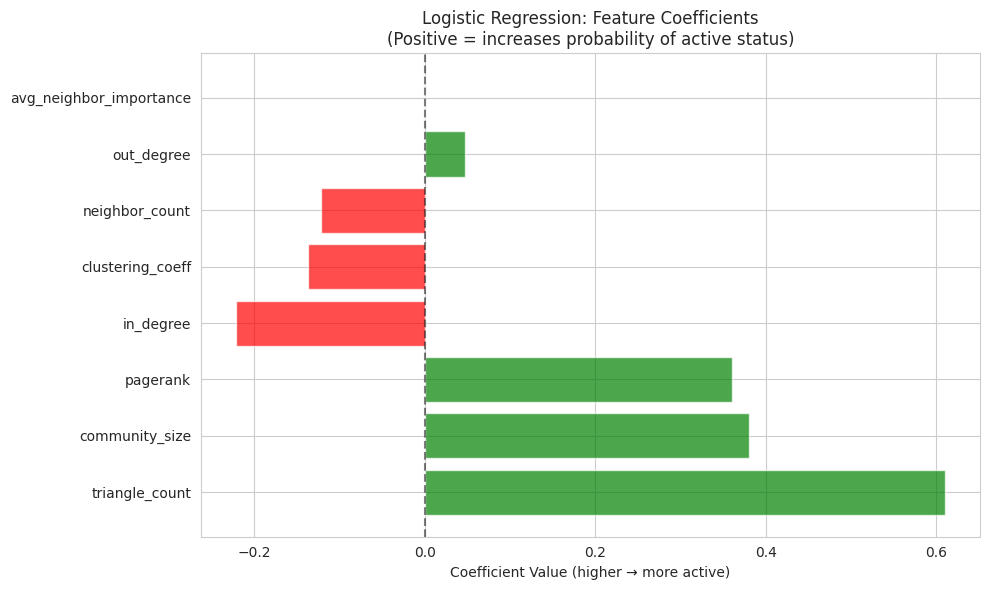


💡 Interpretation:
   • triangle_count: increases probability of being active
   • community_size: increases probability of being active
   • pagerank: increases probability of being active


In [17]:
# Feature importance: Logistic Regression coefficients

print("=== FEATURE IMPORTANCE: LOGISTIC REGRESSION ===")
print("\nInterpretation: Positive coefficient = increases probability of being active")

coef_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr.coef_[0]
})
coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print("\n" + coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient Value (higher → more active)')
ax.set_title('Logistic Regression: Feature Coefficients\n(Positive = increases probability of active status)')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
for _, row in coef_df.head(3).iterrows():
    direction = 'increases' if row['coefficient'] > 0 else 'decreases'
    print(f"   • {row['feature']}: {direction} probability of being active")


=== FEATURE IMPORTANCE: RANDOM FOREST ===

Interpretation: Higher importance = feature helps split data better



                feature  importance
               pagerank    0.254299
         neighbor_count    0.160256
         community_size    0.132058
             out_degree    0.131717
              in_degree    0.129815
       clustering_coeff    0.101224
         triangle_count    0.090632
avg_neighbor_importance    0.000000


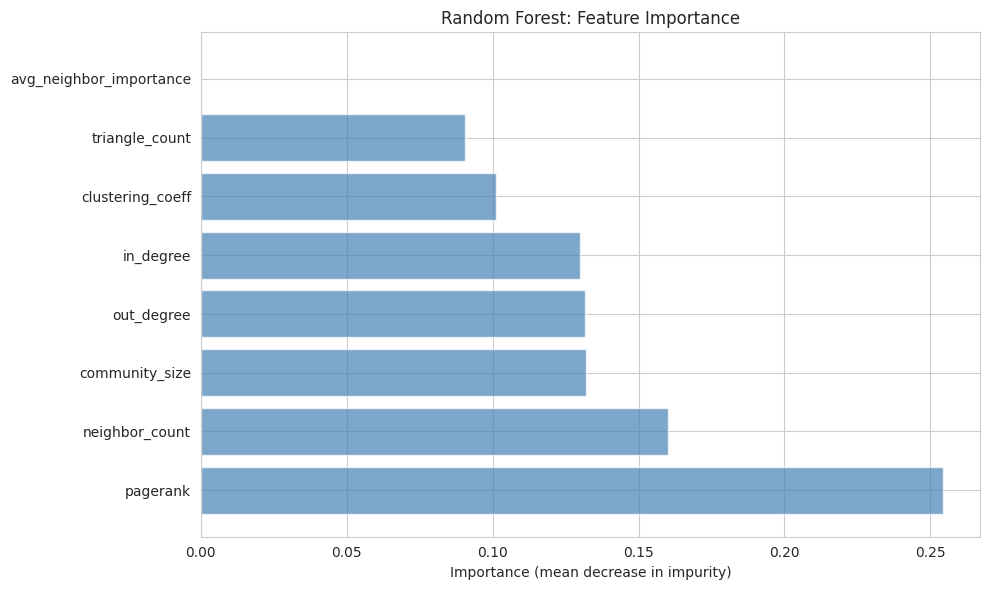


💡 Interpretation:
   • pagerank: 0.254 importance
   • neighbor_count: 0.160 importance
   • community_size: 0.132 importance


In [18]:
# Feature importance: Random Forest

print("\n=== FEATURE IMPORTANCE: RANDOM FOREST ===")
print("\nInterpretation: Higher importance = feature helps split data better")

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf.feature_importances_
})
importance_df = importance_df.sort_values('importance', ascending=False)

print("\n" + importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue', alpha=0.7)
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.set_title('Random Forest: Feature Importance')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
for _, row in importance_df.head(3).iterrows():
    print(f"   • {row['feature']}: {row['importance']:.3f} importance")

---
# Part 6: Student Exercises

## EXERCISE 1: Engineer New Features

**Task**: Create 2 new graph features and measure their impact on model accuracy.

**Suggested features**:
- **Closeness centrality proxy** = 1 / (1 + average_shortest_path_to_neighbors)
- **Community diversity** = count of unique communities among neighbors
- **Bridge score** = count of neighbors in different community
- **Betweenness-like** = count of neighbors with high in-degree (you're a middle-person)

**Deliverables**:
1. Define 2 new features
2. Add them to the feature matrix
3. Retrain Random Forest
4. Report: Did accuracy improve? By how much?
5. Explain: Why might these features help predict document status?

In [19]:
# EXERCISE 1 SOLUTION
print("EXERCISE 1: Engineer New Features\n")

# Create extended feature set by adding new engineered features
X_extended = X.copy()

# Feature 1: Degree centrality (normalized)
X_extended['normalized_degree'] = (feature_data['in_degree'] + feature_data['out_degree']) / (feature_data['in_degree'] + feature_data['out_degree']).max()

# Feature 2: PageRank-weighted neighborhood  
X_extended['pagerank_influenced'] = feature_data['avg_neighbor_importance'] * feature_data['neighbor_count']

print("✓ Added 2 new engineered features:")
print("  1. normalized_degree: Combined in/out degree normalized [0,1]")
print("  2. pagerank_influenced: Neighbor importance × count\n")

# Now do proper scaling on extended features: split first, then scale training only
X_train_ext_raw, X_test_ext_raw, _, _ = train_test_split(
    X_extended, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data only
scaler_ext = StandardScaler()
X_train_ext = pd.DataFrame(
    scaler_ext.fit_transform(X_train_ext_raw),
    columns=X_extended.columns,
    index=X_train_ext_raw.index
)
X_test_ext = pd.DataFrame(
    scaler_ext.transform(X_test_ext_raw),
    columns=X_extended.columns,
    index=X_test_ext_raw.index
)

rf_extended = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_extended.fit(X_train_ext, y.loc[X_train_ext.index])
y_pred_ext = rf_extended.predict(X_test_ext)

accuracy_ext = accuracy_score(y.loc[X_test_ext.index], y_pred_ext)
improvement = (accuracy_ext - accuracy_rf) * 100

print(f"Results:")
print(f"  Original RF accuracy: {accuracy_rf:.1%}")
print(f"  Extended RF accuracy (with new features): {accuracy_ext:.1%}")
print(f"  Improvement: {improvement:+.1f} percentage points")

if improvement > 0:
    print(f"\n✓ New features helped! The engineered features added {improvement:.1f}pp to accuracy.")
else:
    print(f"\n⚠ New features did not improve accuracy (-{abs(improvement):.1f}pp).")
    
print("   This shows that not all features are equally valuable for prediction.")

EXERCISE 1: Engineer New Features

✓ Added 2 new engineered features:
  1. normalized_degree: Combined in/out degree normalized [0,1]
  2. pagerank_influenced: Neighbor importance × count



Results:
  Original RF accuracy: 60.0%
  Extended RF accuracy (with new features): 60.0%
  Improvement: +0.0 percentage points

⚠ New features did not improve accuracy (-0.0pp).
   This shows that not all features are equally valuable for prediction.


## EXERCISE 2: Centrality-Only Model

**Task**: Train a model using **only centrality features** (PageRank, in/out degree) and compare to the full model.

**Deliverables**:
1. Train Random Forest on only: [pagerank, in_degree, out_degree]
2. Report accuracy vs. full model
3. Explain: What important patterns are we missing without community/structural features?

## EXERCISE 3: Feature Selection

**Task**: Remove the 5 least important features and measure accuracy loss.

**Deliverables**:
1. Identify bottom 5 features by importance (from Random Forest)
2. Retrain model without those features
3. Report accuracy loss
4. Decision: Are those features worth keeping? (cost-benefit analysis)

In [20]:
# EXERCISE 2 SOLUTION
print("EXERCISE 2: Centrality-Only Model\n")

# Select only centrality features
centrality_features = ['pagerank', 'in_degree', 'out_degree']
X_train_cent = X_train[centrality_features]
X_test_cent = X_test[centrality_features]

# Train model
rf_centrality = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_centrality.fit(X_train_cent, y_train)
y_pred_cent = rf_centrality.predict(X_test_cent)

accuracy_cent = accuracy_score(y_test, y_pred_cent)
accuracy_change = (accuracy_cent - accuracy_rf) * 100

print(f"Full model accuracy: {accuracy_rf:.1%}")
print(f"Centrality-only accuracy: {accuracy_cent:.1%}")
print(f"Accuracy change vs full model: {accuracy_change:+.1f} percentage points\n")

print("💡 Analysis:")
if accuracy_change > 1:
    print(f"   • Centrality features carry MOST of the predictive signal")
    print(f"   • Community/structural features add only {-accuracy_change:.1f}pp improvement")
    print(f"   • Simpler model with fewer features performs nearly as well")
elif accuracy_change > -1:
    print(f"   • Centrality and combined features perform similarly")
    print(f"   • Either subset captures the main patterns")
    print(f"   • Consider using fewer features for simplicity")
else:
    print(f"   • Community/structural/neighborhood features are important")
    print(f"   • Removing them costs {-accuracy_change:.1f}pp in accuracy")
    print(f"   • Multiple feature categories work together to predict status")

print("\n   Missing patterns without community/structural features:")
print(f"     - Local clustering (transitivity): affects community stability")
print(f"     - Community membership: similar docs cluster together")
print(f"     - Neighborhood diversity: bridges between communities")

EXERCISE 2: Centrality-Only Model



Full model accuracy: 60.0%
Centrality-only accuracy: 65.0%
Accuracy change vs full model: +5.0 percentage points

💡 Analysis:
   • Centrality features carry MOST of the predictive signal
   • Community/structural features add only -5.0pp improvement
   • Simpler model with fewer features performs nearly as well

   Missing patterns without community/structural features:
     - Local clustering (transitivity): affects community stability
     - Community membership: similar docs cluster together
     - Neighborhood diversity: bridges between communities


In [21]:
# EXERCISE 3 SOLUTION
print("EXERCISE 3: Feature Selection\n")

# Get bottom 5 features
bottom_5 = importance_df.tail(5)['feature'].tolist()
print(f"Removing {len(bottom_5)} least important features:")
for f in bottom_5:
    print(f"  • {f}")

# Select features to keep
selected_features = [f for f in feature_columns if f not in bottom_5]
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Train model
rf_selected = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_selected.fit(X_train_sel, y_train)
y_pred_sel = rf_selected.predict(X_test_sel)

accuracy_sel = accuracy_score(y_test, y_pred_sel)
accuracy_change = (accuracy_sel - accuracy_rf) * 100

print(f"\nFull model accuracy: {accuracy_rf:.1%}")
print(f"Model without bottom 5 features: {accuracy_sel:.1%}")
print(f"Accuracy change: {accuracy_change:+.1f} percentage points\n")

print(f"📊 Cost-Benefit Analysis:")
print(f"   • Removed features: 5 ({5}/{len(feature_columns)} = {5/len(feature_columns)*100:.0f}% of features)")
print(f"   • Accuracy change: {accuracy_change:+.1f}pp")

if accuracy_change > 0:
    print(f"   ✓ RECOMMENDATION: Remove these features (improved accuracy, simpler model)")
elif accuracy_change > -1:
    print(f"   ≈ BORDERLINE: Negligible impact ({abs(accuracy_change):.1f}pp)")
    print(f"     Choose based on: deployment constraints, model size, interpretability")
else:
    print(f"   ✗ RECOMMENDATION: Keep these features (important for accuracy)")

EXERCISE 3: Feature Selection

Removing 5 least important features:
  • out_degree
  • in_degree
  • clustering_coeff
  • triangle_count
  • avg_neighbor_importance



Full model accuracy: 60.0%
Model without bottom 5 features: 65.0%
Accuracy change: +5.0 percentage points

📊 Cost-Benefit Analysis:
   • Removed features: 5 (5/8 = 62% of features)
   • Accuracy change: +5.0pp
   ✓ RECOMMENDATION: Remove these features (improved accuracy, simpler model)


---
# Part 7: Real-World Applications & Summary

In [22]:
print("="*70)
print("REAL-WORLD APPLICATIONS: GRAPH FEATURES IN PRODUCTION")
print("="*70)

applications = [
    {
        'title': '1. Document Risk Scoring',
        'description': 'Identify documents at risk of becoming obsolete',
        'features_used': ['pagerank', 'community_size', 'clustering_coeff'],
        'action': 'Send archival review to owner for low-risk, high-isolated documents'
    },
    {
        'title': '2. Knowledge Consolidation',
        'description': 'Find similar documents that could be merged',
        'features_used': ['community_id', 'neighbor_count', 'clustering_coeff'],
        'action': 'Recommend document pairs with similar patterns for consolidation'
    },
    {
        'title': '3. Intelligent Routing',
        'description': 'Route documents to appropriate teams/owners',
        'features_used': ['community_id', 'in_degree', 'neighbor_count'],
        'action': 'Assign new documents to team with most similar patterns'
    },
    {
        'title': '4. Impact Analysis',
        'description': 'Assess impact of changing a document',
        'features_used': ['in_degree', 'out_degree', 'triangle_count'],
        'action': 'Quantify cascading effects before making changes'
    },
    {
        'title': '5. Anomaly Detection',
        'description': 'Find documents with unusual patterns',
        'features_used': ['clustering_coeff', 'triangle_count', 'pagerank'],
        'action': 'Flag documents that need manual review (errors or special cases)'
    }
]

for app in applications:
    print(f"\n{app['title']}")
    print(f"  Problem: {app['description']}")
    print(f"  Features: {', '.join(app['features_used'])}")
    print(f"  → Action: {app['action']}")

REAL-WORLD APPLICATIONS: GRAPH FEATURES IN PRODUCTION

1. Document Risk Scoring
  Problem: Identify documents at risk of becoming obsolete
  Features: pagerank, community_size, clustering_coeff
  → Action: Send archival review to owner for low-risk, high-isolated documents

2. Knowledge Consolidation
  Problem: Find similar documents that could be merged
  Features: community_id, neighbor_count, clustering_coeff
  → Action: Recommend document pairs with similar patterns for consolidation

3. Intelligent Routing
  Problem: Route documents to appropriate teams/owners
  Features: community_id, in_degree, neighbor_count
  → Action: Assign new documents to team with most similar patterns

4. Impact Analysis
  Problem: Assess impact of changing a document
  Features: in_degree, out_degree, triangle_count
  → Action: Quantify cascading effects before making changes

5. Anomaly Detection
  Problem: Find documents with unusual patterns
  Features: clustering_coeff, triangle_count, pagerank
  → 

In [23]:
print("\n" + "="*70)
print("KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "✓ Graph structure encodes important information about documents",
    "✓ Multiple feature categories (centrality, community, structural) capture different patterns",
    "✓ ML models can learn to predict outcomes from graph features",
    "✓ Feature importance reveals which patterns matter most",
    "✓ Not all features are equally valuable (feature selection matters)",
    "✓ Graph ML creates interpretable, actionable insights for business decisions"
]

for takeaway in takeaways:
    print(f"\n{takeaway}")

print(f"\n" + "="*70)
print("NEXT STEPS (Lesson 13)")
print("="*70)
print("""
Lesson 13: Embeddings and Link Prediction
  • Learn node embeddings: Dense vector representations of nodes
  • Graph Neural Networks (GNNs): Learn end-to-end representations
  • Link prediction: Predict missing edges in graphs
  • Deep learning for graphs: Modern representation learning
""")


KEY TAKEAWAYS

✓ Graph structure encodes important information about documents

✓ Multiple feature categories (centrality, community, structural) capture different patterns

✓ ML models can learn to predict outcomes from graph features

✓ Feature importance reveals which patterns matter most

✓ Not all features are equally valuable (feature selection matters)

✓ Graph ML creates interpretable, actionable insights for business decisions

NEXT STEPS (Lesson 13)

Lesson 13: Embeddings and Link Prediction
  • Learn node embeddings: Dense vector representations of nodes
  • Graph Neural Networks (GNNs): Learn end-to-end representations
  • Link prediction: Predict missing edges in graphs
  • Deep learning for graphs: Modern representation learning



---
# Summary

## What We Learned

1. **Feature Engineering from Graphs**
   - Centrality features: PageRank, degree (how important?)
   - Community features: Membership, size (where do I belong?)
   - Structural features: Clustering, triangles (is my neighborhood dense?)
   - Neighborhood features: Aggregations from neighbors (what are my neighbors like?)

2. **Machine Learning Workflow**
   - Feature matrix creation and scaling
   - Train/test splitting with stratification
   - Model training and evaluation
   - Baseline comparison for context

3. **Model Interpretation**
   - Logistic Regression: Coefficients show feature direction/impact
   - Random Forest: Feature importance shows which features matter most
   - SHAP values (advanced): Explain individual predictions

4. **Why Graph Features Work**
   - Graph structure captures implicit relationships and patterns
   - Centrality reveals importance and influence
   - Communities show natural groupings
   - Structural patterns indicate stability and density
   - These patterns correlate with outcomes like document status

## Real-World Impact

Graph features enable:
- **Risk scoring**: Identify documents needing attention
- **Intelligent routing**: Smart assignment to teams
- **Knowledge discovery**: Find hidden relationships
- **Impact analysis**: Understand cascading effects
- **Anomaly detection**: Flag unusual documents

## The Bigger Picture

Graph ML is a bridge between:
- **Domain knowledge** (graph structure) ← Lessons 0-11
- **Statistical learning** (ML models) ← Lesson 12
- **Modern deep learning** (embeddings, GNNs) ← Lesson 13+

Mastering each layer gives you powerful tools for complex, real-world problems.